# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
import pickle

Feature cleaning and definition

In [2]:
# Load data
df = pd.read_csv("final_books_for_classification.csv")

# Data cleaning
df["Price"] = df["Price"].astype(str).str.replace("грн.", "", regex=False).str.replace(",", ".", regex=False).str.extract(r"(\d+\.?\d*)")[0].astype(float)
df["Pages"] = df["Pages"].astype(str).str.extract(r"(\d+)", expand=False).astype(float)
df = df[df["Success_Rate"] <= 100]

# Additional eature engineering
df["Is_Expensive"] = (df["Price"] > 250).astype(int)
df["Price_per_Page"] = df["Price"] / (df["Pages"] + 1)
df["Pages_Category"] = pd.cut(df["Pages"], bins=[0, 100, 300, 1000], labels=["Small", "Medium", "Big"])
df["Price_Category"] = pd.cut(df["Price"], bins=[0, 150, 400, 10000], labels=["Cheap", "Normal", "Expensive"])

# Group rare categories in 'Друкарня'
rare_printers = df["Друкарня"].value_counts()[df["Друкарня"].value_counts() < 5].index
df["Друкарня"] = df["Друкарня"].replace(rare_printers, "Other")

#Feature selection
features = [
    "Author Score", "Pages", "Price", "Production_Year", "Format", "Category", "Subcategory", "Cover Type",
    "Target Audience", "Biblical Level", "Application Type", "Event Relevance", "Content Format", "Друкарня",
    "Is_Expensive", "Price_per_Page", "Pages_Category", "Price_Category"
]
X = df[features]

Define classes

In [3]:
# Target prep (Binary)
def classify_sales_binary(p):
    if p < 25:
        return "Low"
    else:
        return "High"

y_class = df["Success_Rate"].apply(classify_sales_binary)
label_encoder = LabelEncoder()
y_class_enc = label_encoder.fit_transform(y_class)

Preproccessing

In [4]:
# Preprocessing pipeline
numeric = ["Author Score", "Pages", "Price", "Production_Year", "Price_per_Page"]
categorical = list(set(features) - set(numeric))

num_pipe = Pipeline([("imp", SimpleImputer(strategy="mean")), ("scale", MinMaxScaler())])
cat_pipe = Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocessor = ColumnTransformer([("num", num_pipe, numeric), ("cat", cat_pipe, categorical)])
X_processed = preprocessor.fit_transform(X)

# SMOTE balancing
smote = SMOTE(random_state=42)
X_processed, y_class_enc = smote.fit_resample(X_processed, y_class_enc)

Train Logistic Regression/Decision Tree/Random Forest/Naive bayes/ MLP and Evaluations


Model: Logistic Regression
Fold 1
              precision    recall  f1-score   support

        High       0.80      0.69      0.74       128
         Low       0.73      0.83      0.78       129

    accuracy                           0.76       257
   macro avg       0.76      0.76      0.76       257
weighted avg       0.76      0.76      0.76       257

Fold 2
              precision    recall  f1-score   support

        High       0.73      0.67      0.70       128
         Low       0.70      0.75      0.72       129

    accuracy                           0.71       257
   macro avg       0.71      0.71      0.71       257
weighted avg       0.71      0.71      0.71       257

Fold 3
              precision    recall  f1-score   support

        High       0.71      0.61      0.66       129
         Low       0.66      0.74      0.70       128

    accuracy                           0.68       257
   macro avg       0.68      0.68      0.68       257
weighted avg       0.68  

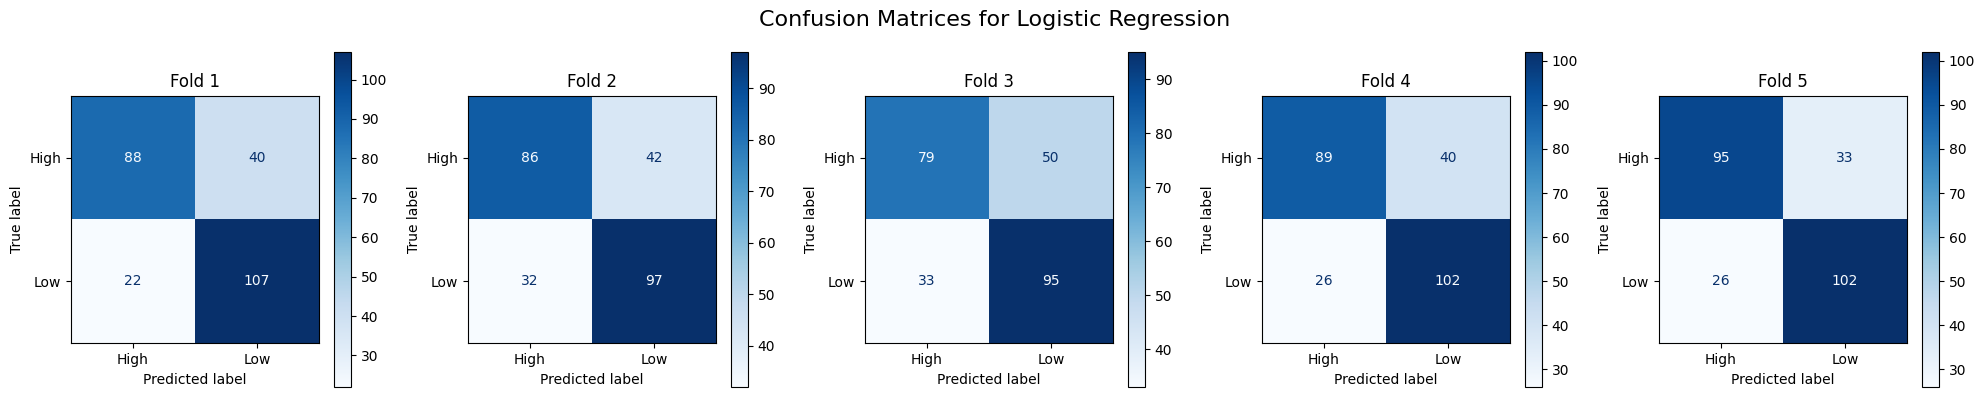

Average Accuracy: 0.7321

Model: Small Decision Tree
Fold 1
              precision    recall  f1-score   support

        High       0.79      0.26      0.39       128
         Low       0.56      0.93      0.70       129

    accuracy                           0.60       257
   macro avg       0.67      0.59      0.54       257
weighted avg       0.67      0.60      0.54       257

Fold 2
              precision    recall  f1-score   support

        High       0.82      0.39      0.53       128
         Low       0.60      0.91      0.73       129

    accuracy                           0.65       257
   macro avg       0.71      0.65      0.63       257
weighted avg       0.71      0.65      0.63       257

Fold 3
              precision    recall  f1-score   support

        High       0.66      0.57      0.61       129
         Low       0.62      0.70      0.66       128

    accuracy                           0.63       257
   macro avg       0.64      0.63      0.63       257


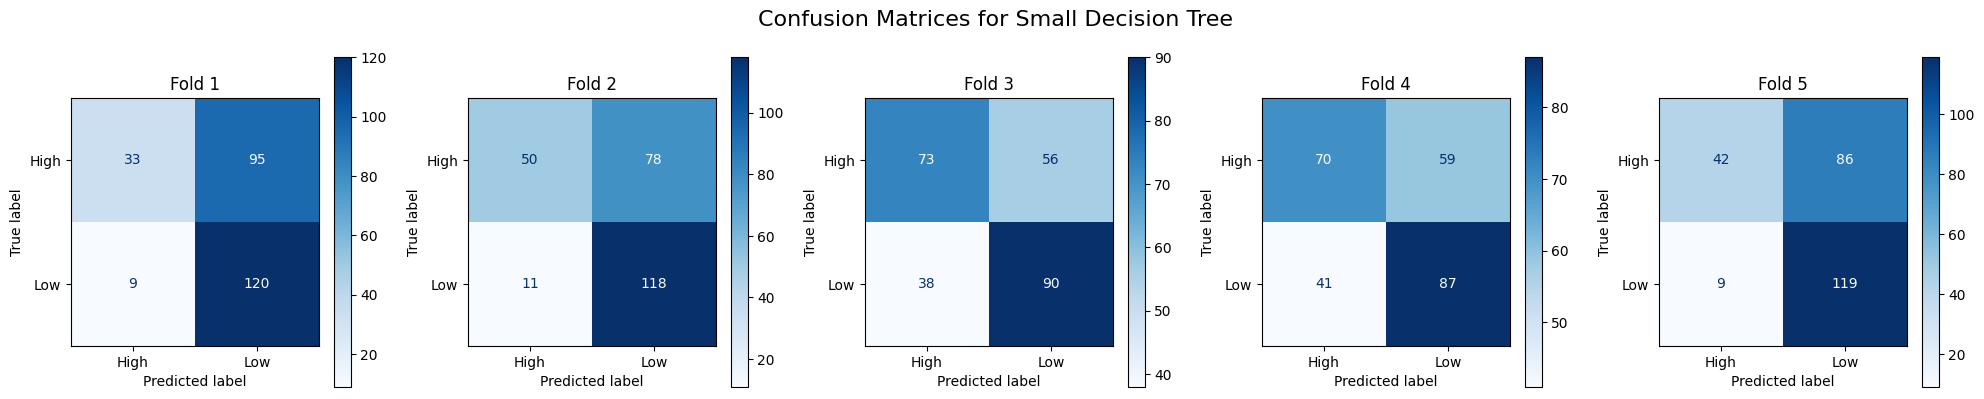

Average Accuracy: 0.6246

Model: Random Forest
Fold 1
              precision    recall  f1-score   support

        High       0.85      0.80      0.83       128
         Low       0.82      0.86      0.84       129

    accuracy                           0.83       257
   macro avg       0.83      0.83      0.83       257
weighted avg       0.83      0.83      0.83       257

Fold 2
              precision    recall  f1-score   support

        High       0.82      0.88      0.85       128
         Low       0.87      0.81      0.84       129

    accuracy                           0.84       257
   macro avg       0.85      0.84      0.84       257
weighted avg       0.85      0.84      0.84       257

Fold 3
              precision    recall  f1-score   support

        High       0.81      0.81      0.81       129
         Low       0.80      0.80      0.80       128

    accuracy                           0.81       257
   macro avg       0.81      0.81      0.81       257
weight

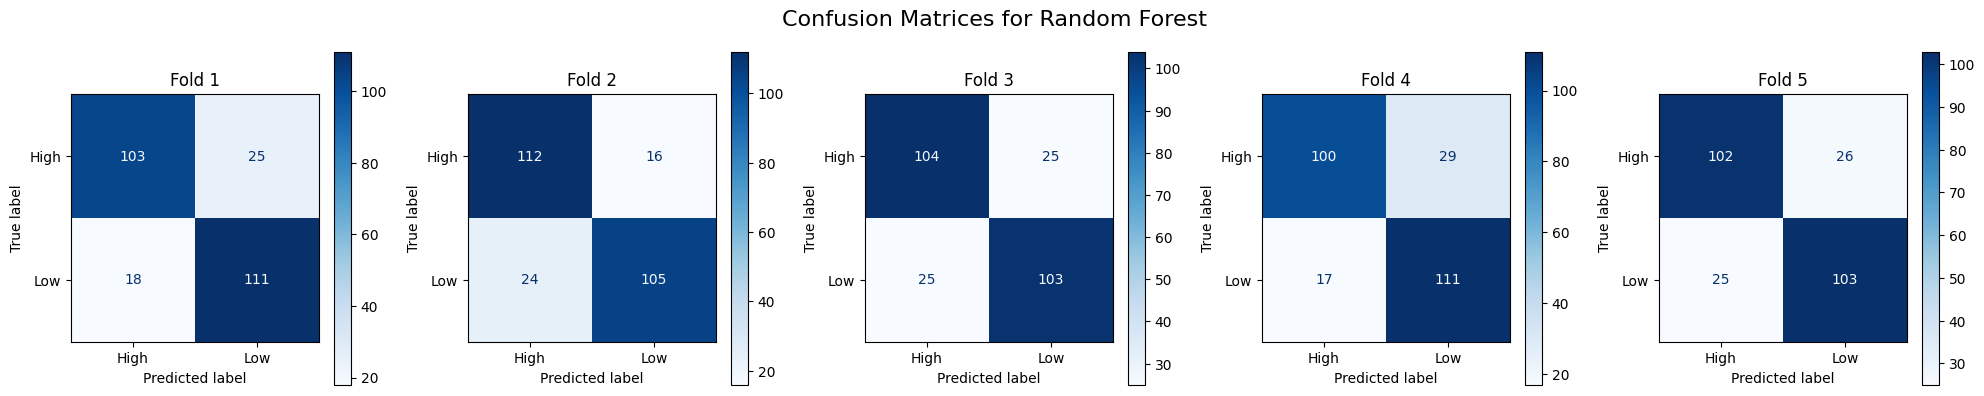

Average Accuracy: 0.8209

Model: Naive Bayes
Fold 1
              precision    recall  f1-score   support

        High       0.84      0.20      0.33       128
         Low       0.55      0.96      0.70       129

    accuracy                           0.58       257
   macro avg       0.69      0.58      0.51       257
weighted avg       0.69      0.58      0.51       257

Fold 2
              precision    recall  f1-score   support

        High       0.84      0.21      0.34       128
         Low       0.55      0.96      0.70       129

    accuracy                           0.59       257
   macro avg       0.70      0.59      0.52       257
weighted avg       0.70      0.59      0.52       257

Fold 3
              precision    recall  f1-score   support

        High       1.00      0.19      0.32       129
         Low       0.55      1.00      0.71       128

    accuracy                           0.60       257
   macro avg       0.78      0.60      0.52       257
weighted

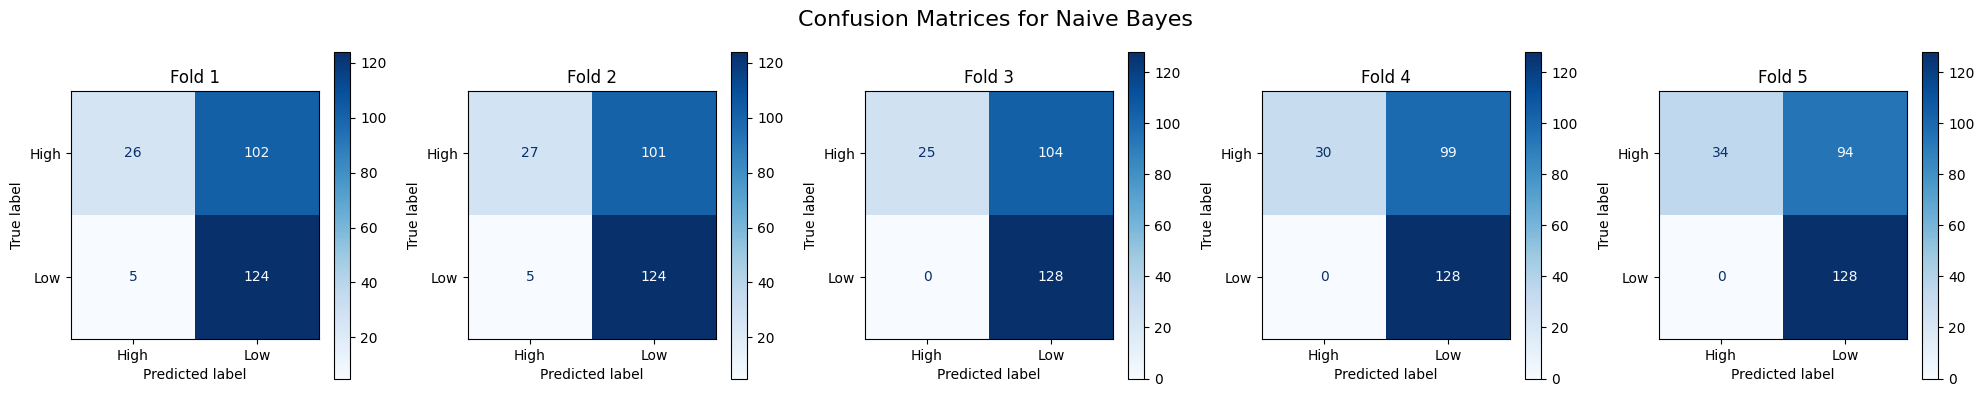

Average Accuracy: 0.6028

Model: MLP Classifier
Fold 1
              precision    recall  f1-score   support

        High       0.95      0.77      0.85       128
         Low       0.81      0.96      0.88       129

    accuracy                           0.87       257
   macro avg       0.88      0.87      0.87       257
weighted avg       0.88      0.87      0.87       257

Fold 2
              precision    recall  f1-score   support

        High       0.94      0.77      0.84       128
         Low       0.80      0.95      0.87       129

    accuracy                           0.86       257
   macro avg       0.87      0.86      0.86       257
weighted avg       0.87      0.86      0.86       257

Fold 3
              precision    recall  f1-score   support

        High       0.94      0.77      0.85       129
         Low       0.80      0.95      0.87       128

    accuracy                           0.86       257
   macro avg       0.87      0.86      0.86       257
weigh

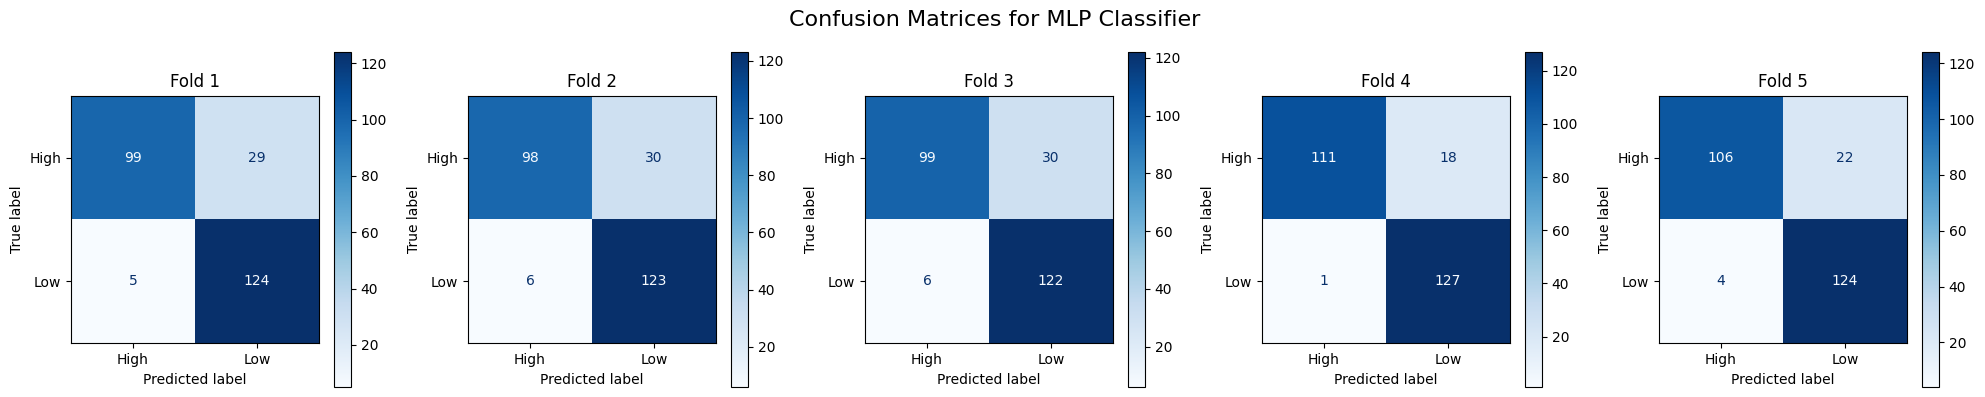

Average Accuracy: 0.8824

Model: Voting Ensemble
Fold 1
              precision    recall  f1-score   support

        High       0.95      0.77      0.85       128
         Low       0.81      0.96      0.88       129

    accuracy                           0.87       257
   macro avg       0.88      0.87      0.87       257
weighted avg       0.88      0.87      0.87       257

Fold 2
              precision    recall  f1-score   support

        High       0.94      0.77      0.85       128
         Low       0.81      0.95      0.88       129

    accuracy                           0.86       257
   macro avg       0.88      0.86      0.86       257
weighted avg       0.88      0.86      0.86       257

Fold 3
              precision    recall  f1-score   support

        High       0.93      0.78      0.85       129
         Low       0.81      0.95      0.87       128

    accuracy                           0.86       257
   macro avg       0.87      0.86      0.86       257
weig

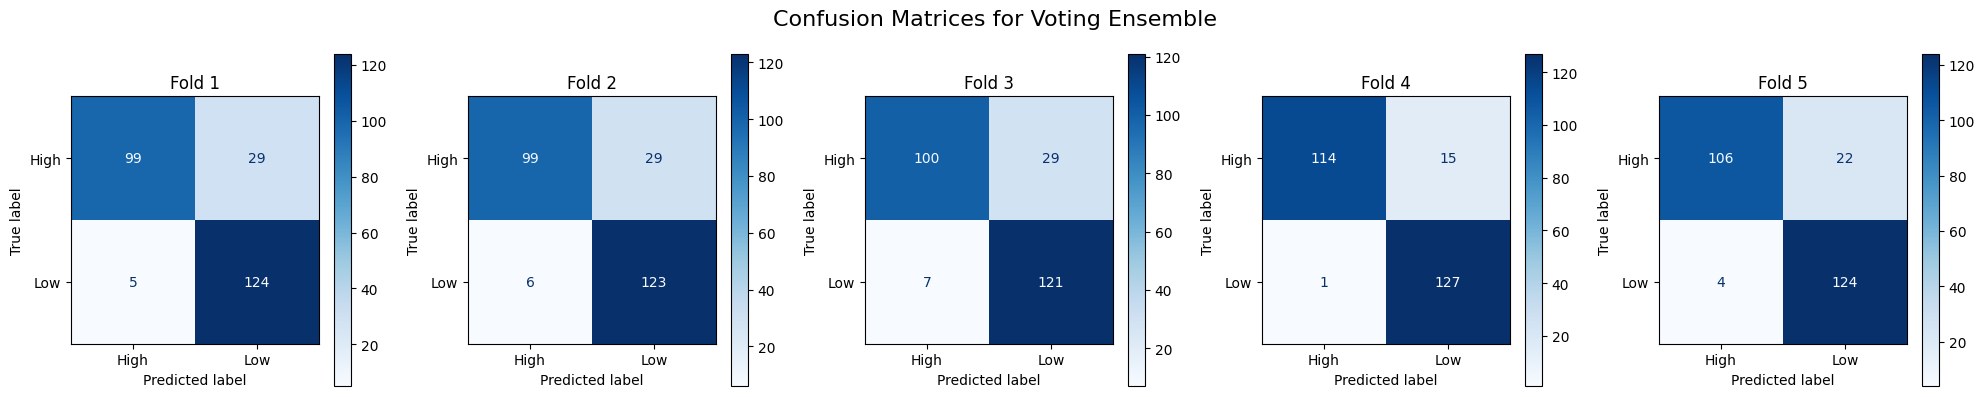

Average Accuracy: 0.8855

 Final Model Accuracies
Logistic Regression: 0.7321
Small Decision Tree: 0.6246
Random Forest: 0.8209
Naive Bayes: 0.6028
MLP Classifier: 0.8824
Voting Ensemble: 0.8855


In [5]:
# Train models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Small Decision Tree": DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=42),
    "Naive Bayes": GaussianNB(),
    "MLP Classifier": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1500, alpha=0.001, random_state=42),
}

# Voting Ensemble
ensemble = VotingClassifier(estimators=[
    ("rf", models["Random Forest"]),
    ("mlp", models["MLP Classifier"])
], voting="soft")
models["Voting Ensemble"] = ensemble

# Evaluation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    print(f"\nModel: {name}")
    fold_accuracies = []

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    axes = axes.flatten()

    for idx, (train_idx, val_idx) in enumerate(skf.split(X_processed, y_class_enc)):
        X_train_fold, X_val_fold = X_processed[train_idx], X_processed[val_idx]
        y_train_fold, y_val_fold = y_class_enc[train_idx], y_class_enc[val_idx]

        model.fit(X_train_fold, y_train_fold)
        y_pred = model.predict(X_val_fold)

        acc = accuracy_score(y_val_fold, y_pred)
        fold_accuracies.append(acc)

        # Classification report
        print(f"Fold {idx + 1}")
        print(classification_report(y_val_fold, y_pred, target_names=label_encoder.classes_))

        # Plot Confusion Matrix
        cm = confusion_matrix(y_val_fold, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
        disp.plot(ax=axes[idx], cmap='Blues')
        axes[idx].set_title(f"Fold {idx + 1}")

    plt.suptitle(f"Confusion Matrices for {name}", fontsize=16)
    plt.tight_layout()
    plt.show()

    avg_acc = np.mean(fold_accuracies)
    results[name] = avg_acc
    print(f"Average Accuracy: {avg_acc:.4f}")

# Step 11: Results summary
print("\n Final Model Accuracies")
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")


Save model details for pipeline

In [6]:
# Save the trained preprocessor
with open("preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

# Save the trained Voting Ensemble model
with open("voting_ensemble.pkl", "wb") as f:
    pickle.dump(ensemble, f)

# Save the author counts (for author score)
author_counts = df["Author"].value_counts().to_dict()
with open("author_counts.pkl", "wb") as f:
    pickle.dump(author_counts, f)

# Save the label encoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)